In [21]:
!pip install datasets

In [22]:
from datasets import load_dataset

ds = load_dataset("data-silence/rus_news_classifier")
train_ds = ds["train"]

In [23]:
ds

DatasetDict({
    train: Dataset({
        features: ['news', 'labels'],
        num_rows: 57530
    })
    test: Dataset({
        features: ['news', 'labels'],
        num_rows: 14383
    })
})

In [24]:
train_ds = ds["train"]

In [25]:
len(train_ds)

57530

In [26]:
train_ds[1]

{'news': 'В 2021 году Microsoft выпустит специальную версию Windows для бюджетных компьютеров. Об этом сообщает издание Windows\xa0Latest. Журналисты выяснили, что операционная система для ПК с двумя экранами — Windows\xa010X — будет иметь особую версию, рассчитанную на слабые компьютеры. Данная система разрабатывалась под названием Windows Lite, но в итоге менеджеры корпорации решили отказаться от него. ОС основана на Windows\xa0Core\xa0OS, она отличается от других операционных систем Microsoft отсутствием меню «Пуск». Вместо этого панель быстрого запуска приложений и сервисов будет находиться по центру рабочего стола. Также новая ОС имеет более яркое и контрастное оформление интерфейса и некоторые отличия в плане дизайна. Windows\xa010X оптимизирована под устройства, имеющие до четырех гигабайт оперативной памяти. Сообщается, что в будущем операционная система будет поддерживать компьютеры с большей емкостью ОЗУ. Вероятно, также она получит поддержку универсальных драйверов Windows. 

In [27]:
politics_ds = train_ds.filter(lambda x: x["labels"] == 6)
sports_ds   = train_ds.filter(lambda x: x["labels"] == 9)

n = min(len(politics_ds), len(sports_ds))

politics_ds = politics_ds.shuffle(seed=42).select(range(n))
sports_ds   = sports_ds.shuffle(seed=42).select(range(n))

In [28]:
print(len(politics_ds))
print(len(sports_ds))

4791
4791


In [29]:
n = min(len(politics_ds), len(sports_ds))

politics_ds = politics_ds.shuffle(seed=42).select(range(n))
sports_ds   = sports_ds.shuffle(seed=42).select(range(n))

In [30]:
print(len(politics_ds))
print(len(sports_ds))

4791
4791


In [31]:
politics_texts = politics_ds["news"]
sports_texts   = sports_ds["news"]

print(len(politics_texts))
print(len(sports_texts))

4791
4791


In [32]:
print(politics_texts[0][:200])

Совет депутатов Калининграда принял досрочную отставку главы города Алексея Силанова, он написал заявление об увольнении по собственному желанию. Об этом сообщает «Интерфакс» в пятницу, 23 октября, со


In [33]:
import re

def tokenize(text):
    text = text.lower()                         # всё в нижний регистр
    text = re.sub(r"[^а-яё\s]", " ", text)     # оставить только русские буквы и пробел
    tokens = text.split()                       # разбить по пробелам
    return tokens

In [34]:
politics_tokens = []
for text in politics_texts:
    politics_tokens.extend(tokenize(text))

sports_tokens = []
for text in sports_texts:
    sports_tokens.extend(tokenize(text))

In [35]:
print(len(politics_tokens))
print(len(sports_tokens))

print(politics_tokens[:20])

724392
609781
['совет', 'депутатов', 'калининграда', 'принял', 'досрочную', 'отставку', 'главы', 'города', 'алексея', 'силанова', 'он', 'написал', 'заявление', 'об', 'увольнении', 'по', 'собственному', 'желанию', 'об', 'этом']


In [36]:
from collections import Counter

politics_counts = Counter(politics_tokens)
sports_counts   = Counter(sports_tokens)

print(politics_counts.most_common(10))
print(sports_counts.most_common(10))

[('в', 30934), ('и', 16863), ('на', 13417), ('что', 13140), ('по', 9149), ('с', 8311), ('не', 6858), ('россии', 5584), ('о', 4801), ('он', 4681)]
[('в', 32253), ('на', 13158), ('и', 12488), ('что', 8637), ('с', 7411), ('по', 6031), ('не', 5681), ('он', 4858), ('за', 4323), ('россии', 3528)]


In [37]:
import math

# общее количество слов
total_politics = sum(politics_counts.values())
total_sports   = sum(sports_counts.values())

# общий словарь
vocab = set(politics_counts.keys()) | set(sports_counts.keys())
V = len(vocab)

print("Размер словаря:", V)

Размер словаря: 81293


In [38]:
log_odds = {}

alpha = 1  # сглаживание

for word in vocab:
    count_p = politics_counts[word]
    count_s = sports_counts[word]

    p_politics = (count_p + alpha) / (total_politics + alpha * V)
    p_sports   = (count_s + alpha) / (total_sports + alpha * V)

    log_odds[word] = math.log(p_politics / p_sports)

In [39]:
sorted_words = sorted(log_odds.items(), key=lambda x: x[1], reverse=True)

print("Топ-30 для политики:")
for word, score in sorted_words[:30]:
    print(word, round(score, 3))

print("\nТоп-30 для спорта:")
for word, score in sorted_words[-30:]:
    print(word, round(score, 3))

Топ-30 для политики:
навального 6.68
всу 5.939
навальный 5.741
киеву 5.547
нато 5.278
фбк 5.267
генерал 5.24
пво 5.094
глав 4.952
военнослужащих 4.89
войск 4.88
поставок 4.857
оппозиционера 4.83
поставки 4.823
навальному 4.816
альянс 4.788
боеприпасов 4.781
уничтожили 4.767
канцлер 4.722
противовоздушной 4.714
ядерного 4.706
оружия 4.701
байден 4.685
вооружения 4.667
коррупцией 4.659
танков 4.634
вооружений 4.617
чвк 4.609
пентагона 4.574
подразделения 4.574

Топ-30 для спорта:
матчей -5.982
тренера -5.994
турнирах -5.994
олимпиаде -6.0
чемпионате -6.013
сборную -6.04
турнире -6.086
турнир -6.12
валиевой -6.142
цска -6.147
матча -6.177
овечкин -6.21
сборной -6.245
форвард -6.263
кубка -6.274
нападающий -6.315
спортсмена -6.338
активе -6.344
сезоне -6.37
поединок -6.398
чемпионат -6.43
олимпийский -6.577
матч -6.63
чемпион -6.69
хоккейной -6.745
тренер -6.757
турнира -6.817
матче -6.841
мок -7.079
нхл -7.106


In [40]:
# длина каждого документа (в токенах)

politics_lengths = []
for text in politics_texts:
    politics_lengths.append(len(tokenize(text)))

sports_lengths = []
for text in sports_texts:
    sports_lengths.append(len(tokenize(text)))

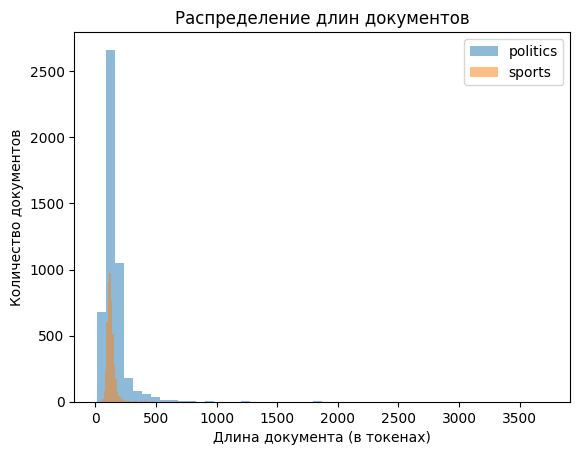

In [41]:
import matplotlib.pyplot as plt

plt.hist(politics_lengths, bins=50, alpha=0.5, label="politics")
plt.hist(sports_lengths, bins=50, alpha=0.5, label="sports")

plt.legend()
plt.xlabel("Длина документа (в токенах)")
plt.ylabel("Количество документов")
plt.title("Распределение длин документов")

plt.show()

In [42]:
# получаем топ-100 слов по частоте
top100_politics = politics_counts.most_common(100)
top100_sports   = sports_counts.most_common(100)

# ранги
ranks = list(range(1, 101))

# частоты
freq_politics = [freq for word, freq in top100_politics]
freq_sports   = [freq for word, freq in top100_sports]

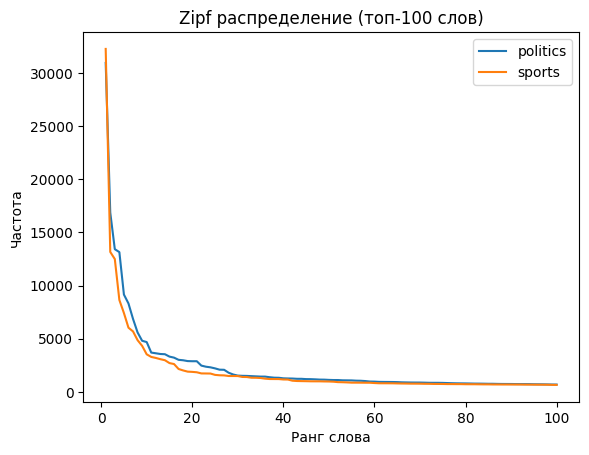

In [43]:
plt.plot(ranks, freq_politics, label="politics")
plt.plot(ranks, freq_sports, label="sports")

plt.xlabel("Ранг слова")
plt.ylabel("Частота")
plt.title("Zipf распределение (топ-100 слов)")
plt.legend()

plt.show()

In [44]:
# простой список стоп-слов (минимальный базовый)
stop_words = {
    "в","и","на","с","по","что","не","о","он","она","это","как","а","то",
    "за","к","из","у","от","для","его","ее","их","мы","вы","они","же"
}

In [45]:
def tokenize_no_stop(text):
    text = text.lower()
    text = re.sub(r"[^а-яё\s]", " ", text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]
    return tokens

In [46]:
# Новая токенизация
politics_tokens_ns = []
for text in politics_texts:
    politics_tokens_ns.extend(tokenize_no_stop(text))

sports_tokens_ns = []
for text in sports_texts:
    sports_tokens_ns.extend(tokenize_no_stop(text))

In [47]:
print(len(politics_tokens_ns))
print(len(sports_tokens_ns))
print(politics_tokens_ns[:20])

581632
488189
['совет', 'депутатов', 'калининграда', 'принял', 'досрочную', 'отставку', 'главы', 'города', 'алексея', 'силанова', 'написал', 'заявление', 'об', 'увольнении', 'собственному', 'желанию', 'об', 'этом', 'сообщает', 'интерфакс']


In [48]:
from collections import Counter

politics_counts_ns = Counter(politics_tokens_ns)
sports_counts_ns   = Counter(sports_tokens_ns)

In [49]:
total_politics_ns = sum(politics_counts_ns.values())
total_sports_ns   = sum(sports_counts_ns.values())

vocab_ns = set(politics_counts_ns.keys()) | set(sports_counts_ns.keys())
V_ns = len(vocab_ns)

log_odds_ns = {}

alpha = 1

for word in vocab_ns:
    count_p = politics_counts_ns[word]
    count_s = sports_counts_ns[word]

    p_politics = (count_p + alpha) / (total_politics_ns + alpha * V_ns)
    p_sports   = (count_s + alpha) / (total_sports_ns + alpha * V_ns)

    log_odds_ns[word] = math.log(p_politics / p_sports)

In [50]:
sorted_words_ns = sorted(log_odds_ns.items(), key=lambda x: x[1], reverse=True)

print("Топ-30 для политики (без стоп-слов):")
for word, score in sorted_words_ns[:30]:
    print(word, round(score, 3))

print("\nТоп-30 для спорта (без стоп-слов):")
for word, score in sorted_words_ns[-30:]:
    print(word, round(score, 3))

Топ-30 для политики (без стоп-слов):
навального 6.681
всу 5.94
навальный 5.742
киеву 5.549
нато 5.28
фбк 5.269
генерал 5.242
пво 5.095
глав 4.954
военнослужащих 4.891
войск 4.882
поставок 4.859
оппозиционера 4.832
поставки 4.825
навальному 4.818
альянс 4.79
боеприпасов 4.783
уничтожили 4.768
канцлер 4.723
противовоздушной 4.716
ядерного 4.708
оружия 4.703
байден 4.687
вооружения 4.668
коррупцией 4.66
танков 4.636
вооружений 4.619
чвк 4.61
пентагона 4.575
подразделения 4.575

Топ-30 для спорта (без стоп-слов):
матчей -5.981
тренера -5.993
турнирах -5.993
олимпиаде -5.998
чемпионате -6.011
сборную -6.038
турнире -6.084
турнир -6.118
валиевой -6.141
цска -6.146
матча -6.175
овечкин -6.209
сборной -6.243
форвард -6.261
кубка -6.272
нападающий -6.313
спортсмена -6.336
активе -6.342
сезоне -6.369
поединок -6.396
чемпионат -6.429
олимпийский -6.575
матч -6.629
чемпион -6.689
хоккейной -6.744
тренер -6.756
турнира -6.815
матче -6.839
мок -7.078
нхл -7.105


In [51]:
!pip uninstall -y pymorphy2
!pip install pymorphy2==0.9.1

Found existing installation: pymorphy2 0.9.1
Uninstalling pymorphy2-0.9.1:
  Successfully uninstalled pymorphy2-0.9.1
  Using cached pymorphy2-0.9.1-py3-none-any.whl.metadata (3.6 kB)
Using cached pymorphy2-0.9.1-py3-none-any.whl (55 kB)


In [52]:
!pip install pymorphy3

In [53]:
import pymorphy3

morph = pymorphy3.MorphAnalyzer()

In [54]:
def tokenize_lemma(text):
    text = text.lower()
    text = re.sub(r"[^а-яё\s]", " ", text)
    tokens = text.split()

    lemmas = []
    for t in tokens:
        if t not in stop_words:
            lemma = morph.parse(t)[0].normal_form
            lemmas.append(lemma)

    return lemmas

In [55]:
politics_tokens_lemma = []
for text in politics_texts:
    politics_tokens_lemma.extend(tokenize_lemma(text))

sports_tokens_lemma = []
for text in sports_texts:
    sports_tokens_lemma.extend(tokenize_lemma(text))

In [56]:
from collections import Counter

politics_counts_lemma = Counter(politics_tokens_lemma)
sports_counts_lemma   = Counter(sports_tokens_lemma)

print(len(politics_counts_lemma))
print(len(sports_counts_lemma))

23679
19585


In [57]:
import math

total_politics_lemma = sum(politics_counts_lemma.values())
total_sports_lemma   = sum(sports_counts_lemma.values())

vocab_lemma = set(politics_counts_lemma.keys()) | set(sports_counts_lemma.keys())
V_lemma = len(vocab_lemma)

print("Размер общего словаря:", V_lemma)

Размер общего словаря: 33002


In [58]:
log_odds_lemma = {}
alpha = 1

for word in vocab_lemma:
    count_p = politics_counts_lemma[word]
    count_s = sports_counts_lemma[word]

    p_politics = (count_p + alpha) / (total_politics_lemma + alpha * V_lemma)
    p_sports   = (count_s + alpha) / (total_sports_lemma + alpha * V_lemma)

    log_odds_lemma[word] = math.log(p_politics / p_sports)

In [59]:
sorted_words_lemma = sorted(log_odds_lemma.items(), key=lambda x: x[1], reverse=True)

print("Топ-30 для политики (лемматизация):")
for word, score in sorted_words_lemma[:30]:
    print(word, round(score, 3))

print("\nТоп-30 для спорта (лемматизация):")
for word, score in sorted_words_lemma[-30:]:
    print(word, round(score, 3))

Топ-30 для политики (лемматизация):
навальный 7.182
всу 5.928
вооружение 5.746
генерал 5.481
обстрел 5.422
боеприпас 5.303
оппозиционер 5.278
нато 5.267
канцлер 5.26
фбк 5.256
оборонный 5.118
пво 5.082
пентагон 4.971
эрдоган 4.885
газопровод 4.839
поставка 4.762
альянс 4.745
противовоздушный 4.733
истребитель 4.718
артиллерийский 4.71
поток 4.687
тайвань 4.687
североатлантический 4.687
танк 4.683
артиллерия 4.679
беспилотный 4.655
ракетный 4.651
войско 4.639
летательный 4.631
чвк 4.597

Топ-30 для спорта (лемматизация):
катание -5.835
кхл -5.852
спартак -5.895
гимнастика -5.895
емельяненко -5.901
тутберидзе -5.905
чемпион -5.908
спортсменка -5.908
хоккеист -5.944
чемпионат -5.989
фигурист -6.139
антидопинговый -6.139
цска -6.159
титул -6.193
хоккейный -6.21
тренер -6.275
очко -6.279
сборная -6.312
шайба -6.387
атлет -6.505
овечкин -6.526
поединок -6.671
форвард -6.672
футболист -6.688
валиев -6.786
кубок -6.829
матч -6.926
мокнуть -7.091
нхл -7.118
турнир -7.365


In [60]:
# Part B — Naive Bayes + Authorship Attribution

In [66]:
import os
print(os.listdir())

['.config', 'sample_data']


In [67]:
from google.colab import files
uploaded = files.upload()

Saving poems.csv to poems.csv


In [68]:
import os
print(os.listdir())

['.config', 'poems.csv', 'sample_data']


In [69]:
import pandas as pd

df = pd.read_csv("poems.csv")
df.head()

,writer,poem,text
0,Лермонтов Михаил Юрьевич,Любовь мертвеца,NaN
1,Лермонтов Михаил Юрьевич,На серебряные шпоры…,На серебряные шпоры\nЯ в раздумии гляжу;\nЗа т...
2,Лермонтов Михаил Юрьевич,Вид гор из степей Козлова,Пилигрим\nАллах ли там среди пустыни\nЗастывши...
3,Лермонтов Михаил Юрьевич,"К (О, не скрывай! Ты плакала об нем…)","О, не скрывай! Ты плакала об нем –\nИ я его лю..."
4,Лермонтов Михаил Юрьевич,"Жалобы турка (письмо к другу, иностранцу)","Ты знал ли дикий край, под знойными лучами,\nГ..."


In [70]:
print(df.columns)
print("Всего строк:", len(df))
print("\nТоп авторов:")
print(df["writer"].value_counts().head(10))

Index(['writer', 'poem', 'text'], dtype='object')
Всего строк: 19316

Топ авторов:
writer
Брюсов Валерий Яковлевич            1607
Игорь Северянин                     1597
Александр Петрович Сумароков        1520
Блок Александр Александрович        1282
Маяковский Владимир Владимирович    1279
Фёдор Кузьмич Сологуб               1163
Бальмонт Константин Дмитриевич       990
Фет Афанасий Афанасьевич             888
Пушкин Александр Сергеевич           763
Цветаева Марина Ивановна             535
Name: count, dtype: int64


In [71]:
df = df.dropna(subset=["text"])
print("После удаления NaN:", len(df))

После удаления NaN: 19302


In [72]:
authors = [
    "Брюсов Валерий Яковлевич",
    "Маяковский Владимир Владимирович"
]

df_two = df[df["writer"].isin(authors)]

print(df_two["writer"].value_counts())

writer
Брюсов Валерий Яковлевич            1607
Маяковский Владимир Владимирович    1279
Name: count, dtype: int64


In [73]:
import re

def tokenize_simple(text):
    text = str(text).lower()
    text = re.sub(r"[^а-яё\s]", " ", text)
    return text.split()

In [74]:
def make_chunks(tokens, chunk_size=200, min_size=80):
    chunks = []
    for i in range(0, len(tokens), chunk_size):
        chunk = tokens[i:i+chunk_size]
        if len(chunk) >= min_size:
            chunks.append(" ".join(chunk))
    return chunks

In [75]:
X = []
y = []

for _, row in df_two.iterrows():
    tokens = tokenize_simple(row["text"])
    chunks = make_chunks(tokens, chunk_size=200, min_size=80)

    X.extend(chunks)
    y.extend([row["writer"]] * len(chunks))

print("Всего чанков:", len(X))
print("Пример чанка:\n", X[0][:300])

Всего чанков: 2511
Пример чанка:
 сегодня пролетариат гром голосов раскуй забудь о всепрощеньи воске приконченный фашистской шайкой воровско й в последний раз москвой пройдет воровский сколько не станет сколько не стало скольких в клочья скольких в дым где б ни сдали чья б ни сдала мы не сдали мы не сдадим сегодня гнев скругли в огр


In [76]:
from collections import Counter
print(Counter(y))

Counter({'Маяковский Владимир Владимирович': 1344, 'Брюсов Валерий Яковлевич': 1167})


In [77]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", len(X_train))
print("Test:", len(X_test))

Train: 2008
Test: 503


In [78]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Размер матрицы train:", X_train_vec.shape)

Размер матрицы train: (2008, 65305)


In [79]:
from sklearn.naive_bayes import MultinomialNB

clf = MultinomialNB()
clf.fit(X_train_vec, y_train)

MultinomialNB()

In [80]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = clf.predict(X_test_vec)

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred))

Confusion matrix:
[[230   4]
 [  2 267]]

Classification report:
                                  precision    recall  f1-score   support

        Брюсов Валерий Яковлевич       0.99      0.98      0.99       234
Маяковский Владимир Владимирович       0.99      0.99      0.99       269

                        accuracy                           0.99       503
                       macro avg       0.99      0.99      0.99       503
                    weighted avg       0.99      0.99      0.99       503



In [81]:
import numpy as np

feature_names = np.array(vectorizer.get_feature_names_out())

# лог-вероятности
log_probs = clf.feature_log_prob_

# разница между классами
delta = log_probs[0] - log_probs[1]

# сортировка
top_idx = np.argsort(delta)

print("Топ-20 слов для Брюсова:")
for i in top_idx[-20:]:
    print(feature_names[i], round(delta[i], 3))

print("\nТоп-20 слов для Маяковского:")
for i in top_idx[:20]:
    print(feature_names[i], round(delta[i], 3))

Топ-20 слов для Брюсова:
былое 3.376
ласк 3.42
взоры 3.42
смутно 3.42
тайной 3.463
тайну 3.463
вздох 3.463
влечет 3.463
прогност 3.463
синарет 3.543
священный 3.543
поцелуй 3.543
трепет 3.581
миги 3.652
мечты 3.694
былом 3.719
порой 3.923
тайны 4.135
мгле 4.49
иль 4.552

Топ-20 слов для Маяковского:
вставка -5.09
победоносиков -4.699
тексте -4.657
вместо -4.62
рабочих -4.46
оптимистенко -4.388
реплика -4.279
мол -4.237
отсутствуют -4.192
рабочие -4.146
зря -4.084
батрак -4.019
отсутствует -3.963
нечистые -3.935
товарищ -3.931
присыпкин -3.92
текст -3.92
рабочего -3.905
поп -3.889
кузнец -3.826


In [82]:
import pymorphy3

morph = pymorphy3.MorphAnalyzer()

def lemmatize_text(text):
    text = str(text).lower()
    text = re.sub(r"[^а-яё\s]", " ", text)
    tokens = text.split()

    lemmas = []
    for t in tokens:
        lemma = morph.parse(t)[0].normal_form
        lemmas.append(lemma)

    return lemmas

In [84]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer_lemma = CountVectorizer(analyzer=lemmatize_text)

X_train_lemma = vectorizer_lemma.fit_transform(X_train)
X_test_lemma = vectorizer_lemma.transform(X_test)

In [85]:
clf_lemma = MultinomialNB()
clf_lemma.fit(X_train_lemma, y_train)

y_pred_lemma = clf_lemma.predict(X_test_lemma)

print(classification_report(y_test, y_pred_lemma))

                                  precision    recall  f1-score   support

        Брюсов Валерий Яковлевич       0.98      0.99      0.98       234
Маяковский Владимир Владимирович       0.99      0.98      0.99       269

                        accuracy                           0.98       503
                       macro avg       0.98      0.98      0.98       503
                    weighted avg       0.98      0.98      0.98       503



In [86]:
import numpy as np

feature_names_lemma = np.array(vectorizer_lemma.get_feature_names_out())
log_probs_lemma = clf_lemma.feature_log_prob_

delta_lemma = log_probs_lemma[0] - log_probs_lemma[1]
top_idx_lemma = np.argsort(delta_lemma)

print("Топ-20 для Брюсова (лемматизация):")
for i in top_idx_lemma[-20:]:
    print(feature_names_lemma[i], round(delta_lemma[i], 3))

print("\nТоп-20 для Маяковского (лемматизация):")
for i in top_idx_lemma[:20]:
    print(feature_names_lemma[i], round(delta_lemma[i], 3))

Топ-20 для Брюсова (лемматизация):
безумный 3.762
обмануть 3.762
былой 3.77
чара 3.795
ветвь 3.795
шумный 3.827
звучать 3.827
сосна 3.916
предел 3.916
тайна 3.958
порой 3.999
напев 3.999
трепет 4.025
таинственный 4.122
жгучий 4.145
мгла 4.153
пир 4.19
пламенный 4.293
сумрачный 4.368
иль 4.628

Топ-20 для Маяковского (лемматизация):
текст -5.172
вставка -5.094
реплика -5.064
отсутствовать -4.708
победоносик -4.623
вместо -4.546
буржуй -4.443
гражданин -4.321
оптимистенко -4.312
крестьянин -4.214
рабочий -4.198
класс -4.139
батрак -4.046
действие -4.021
зря -4.008
присыпкин -3.983
орать -3.929
фосфорический -3.916
чудак -3.888
кузнец -3.888


In [87]:
vectorizer_ngram = CountVectorizer(
    ngram_range=(1,2),
    max_features=30000
)

X_train_ng = vectorizer_ngram.fit_transform(X_train)
X_test_ng = vectorizer_ngram.transform(X_test)

clf_ng = MultinomialNB()
clf_ng.fit(X_train_ng, y_train)

y_pred_ng = clf_ng.predict(X_test_ng)

print(classification_report(y_test, y_pred_ng))

                                  precision    recall  f1-score   support

        Брюсов Валерий Яковлевич       0.99      0.99      0.99       234
Маяковский Владимир Владимирович       0.99      0.99      0.99       269

                        accuracy                           0.99       503
                       macro avg       0.99      0.99      0.99       503
                    weighted avg       0.99      0.99      0.99       503



In [88]:
chunk_lengths = [len(text.split()) for text in X]

import numpy as np

print("Средняя длина:", np.mean(chunk_lengths))
print("Мин:", np.min(chunk_lengths))
print("Макс:", np.max(chunk_lengths))

Средняя длина: 156.61768219832737
Мин: 80
Макс: 200


In [89]:
X_long = []
y_long = []

X_short = []
y_short = []

for text, label in zip(X, y):
    length = len(text.split())

    if length >= 200:
        X_long.append(text)
        y_long.append(label)

    if 80 <= length <= 120:
        X_short.append(text)
        y_short.append(label)

print("Long:", len(X_long))
print("Short:", len(X_short))

Long: 1086
Short: 758


In [90]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

# Векторизация
vectorizer_shift = CountVectorizer()

X_long_vec = vectorizer_shift.fit_transform(X_long)
X_short_vec = vectorizer_shift.transform(X_short)

# Обучение
clf_shift = MultinomialNB()
clf_shift.fit(X_long_vec, y_long)

# Предсказание
y_pred_shift = clf_shift.predict(X_short_vec)

print(classification_report(y_short, y_pred_shift))

                                  precision    recall  f1-score   support

        Брюсов Валерий Яковлевич       0.99      0.93      0.96       570
Маяковский Владимир Владимирович       0.82      0.98      0.89       188

                        accuracy                           0.94       758
                       macro avg       0.91      0.96      0.93       758
                    weighted avg       0.95      0.94      0.94       758

